## ASSIGNMENT NO.: 08
### Title: AI Security Implementation for Adversarial Attack and Data Breach Protection

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

2026-03-16 10:44:48.110034: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 10:44:48.111580: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 10:44:48.134739: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-16 10:44:48.134765: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-16 10:44:48.135340: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [13]:
train = pd.read_csv("../admin1/Downloads/mnist_train.csv")
test = pd.read_csv("../admin1/Downloads/mnist_test.csv")

print(train.head())

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [15]:
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]

In [17]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [19]:
X_train = np.array(X_train)
X_test = np.array(X_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [21]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [23]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


In [33]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np

In [37]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [39]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
938/938 [==============================] - 8s 9ms/step - loss: 0.1568 - accuracy: 0.9536 - val_loss: 0.0457 - val_accuracy: 0.9850
Epoch 2/5
938/938 [==============================] - 8s 8ms/step - loss: 0.0471 - accuracy: 0.9854 - val_loss: 0.0332 - val_accuracy: 0.9886
Epoch 3/5
938/938 [==============================] - 8s 8ms/step - loss: 0.0338 - accuracy: 0.9891 - val_loss: 0.0313 - val_accuracy: 0.9895
Epoch 4/5
938/938 [==============================] - 8s 8ms/step - loss: 0.0246 - accuracy: 0.9926 - val_loss: 0.0272 - val_accuracy: 0.9910
Epoch 5/5
938/938 [==============================] - 8s 8ms/step - loss: 0.0192 - accuracy: 0.9940 - val_loss: 0.0282 - val_accuracy: 0.9896


In [43]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.0282 - accuracy: 0.9896
Test Accuracy: 0.9896000027656555


In [47]:
epsilon = 0.1

# Convert to Tensor
x_sample = tf.convert_to_tensor(X_test[:100], dtype=tf.float32)
y_sample = tf.convert_to_tensor(y_test[:100], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(x_sample)
    prediction = model(x_sample)
    loss = tf.keras.losses.categorical_crossentropy(y_sample, prediction)

gradient = tape.gradient(loss, x_sample)

signed_grad = tf.sign(gradient)

x_adv = x_sample + epsilon * signed_grad

x_adv = tf.clip_by_value(x_adv, 0, 1)

In [49]:
pred_adv = model.predict(x_adv)

adv_accuracy = np.mean(
    np.argmax(pred_adv, axis=1) == np.argmax(y_test[:100], axis=1)
)

print("Accuracy on adversarial samples:", adv_accuracy)

4/4 [==============================] - 0s 3ms/step
Accuracy on adversarial samples: 0.85


In [51]:
X_combined = np.concatenate((X_train[:1000], x_adv))
Y_combined = np.concatenate((y_train[:1000], y_test[:100]))

model.fit(X_combined, Y_combined, epochs=3)

Epoch 1/3
35/35 [==============================] - 0s 5ms/step - loss: 0.0571 - accuracy: 0.9827
Epoch 2/3
35/35 [==============================] - 0s 5ms/step - loss: 0.0096 - accuracy: 0.9973
Epoch 3/3
35/35 [==============================] - 0s 5ms/step - loss: 0.0041 - accuracy: 1.0000


In [53]:
pred_adv2 = model.predict(x_adv)

adv_accuracy2 = np.mean(
    np.argmax(pred_adv2, axis=1) == np.argmax(y_test[:100], axis=1)
)

print("Accuracy after defense:", adv_accuracy2)

4/4 [==============================] - 0s 2ms/step
Accuracy after defense: 1.0


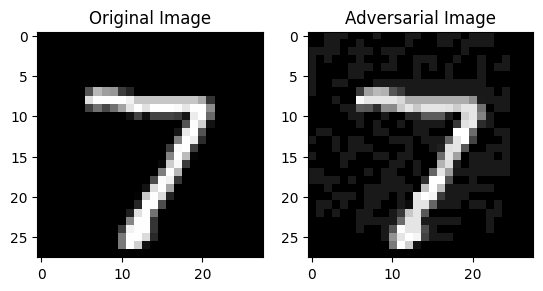

In [55]:
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(X_test[0].reshape(28,28), cmap="gray")

plt.subplot(1,2,2)
plt.title("Adversarial Image")
plt.imshow(x_adv[0].numpy().reshape(28,28), cmap="gray")

plt.show()